# ELSST Track 1: Results & Analysis

## Master Results Table
> Consolidates every method tested across Sections 3-9 into a single comparison, using final corrected numbers post parsing-completeness fix where applicable. All results are on the full 756-document validation set except Standard RAG, which is a 100-document
ablation noted explicitly rather than presented as directly comparable.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
project_path = '/content/drive/MyDrive/ELSST_Project'
RESULTS_DIR = os.path.join(project_path, 'results')

results_files = {
    'TF-IDF': 'tfidf_baseline.json',
    'BM25': 'bm25_baseline.json',
    'Sentence-BERT': 'sbert_baseline.json',
    'Qwen3-Embedding': 'qwen_baseline.json',
    'Zero-shot': 'zero_shot_retrieval.json',
    'Few-shot': 'few_shot_retrieval.json',
    'CoT': 'cot_retrieval.json',
    'Hierarchy (specificity)': 'hierarchy_specificity_retrieval.json',
    'Standard RAG (n=100)': 'standard_rag_retrieval.json',
    'OG-RAG': 'og_rag_retrieval.json',
    'Novel Pipeline': 'novel_pipeline_retrieval.json',
}

master_results = {}
missing = []
for name, fname in results_files.items():
    path = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(path):
        with open(path) as f:
            master_results[name] = json.load(f)
    else:
        missing.append(fname)

if missing:
    print(f"Missing files (will need to recompute or locate): {missing}")

print(f"\nLoaded {len(master_results)}/{len(results_files)} results\n")
for name, metrics in master_results.items():
    print(f"{name:26s}  MRR: {metrics['MRR']:.4f}  R@5: {metrics['Recall@5']:.4f}  "
          f"R@10: {metrics['Recall@10']:.4f}  NDCG@10: {metrics['NDCG@10']:.4f}")

Mounted at /content/drive
Missing files (will need to recompute or locate): ['zero_shot_retrieval.json', 'few_shot_retrieval.json', 'cot_retrieval.json']

Loaded 8/11 results

TF-IDF                      MRR: 0.3182  R@5: 0.2209  R@10: 0.2894  NDCG@10: 0.2234
BM25                        MRR: 0.2800  R@5: 0.1803  R@10: 0.2367  NDCG@10: 0.1927
Sentence-BERT               MRR: 0.3203  R@5: 0.2304  R@10: 0.3146  NDCG@10: 0.2344
Qwen3-Embedding             MRR: 0.3678  R@5: 0.2769  R@10: 0.3618  NDCG@10: 0.2826
Hierarchy (specificity)     MRR: 0.3669  R@5: 0.2752  R@10: 0.3607  NDCG@10: 0.2816
Standard RAG (n=100)        MRR: 0.5229  R@5: 0.4577  R@10: 0.5398  NDCG@10: 0.4483
OG-RAG                      MRR: 0.4970  R@5: 0.3948  R@10: 0.5019  NDCG@10: 0.4048
Novel Pipeline              MRR: 0.4898  R@5: 0.3941  R@10: 0.4928  NDCG@10: 0.4004


In [2]:
result_files_actual = sorted(os.listdir(RESULTS_DIR))
for f in result_files_actual:
    print(f)

baseline_comparison.csv
bm25_baseline.json
bm25_predictions.json
chain_of_thought_prompting.json
concept_hierarchy_strict.json
cot_predictions.json
few_shot_predictions.json
few_shot_prompting.json
hierarchy_aware_normalized_predictions.json
hierarchy_aware_normalized_retrieval.json
hierarchy_aware_predictions.json
hierarchy_aware_retrieval.json
hierarchy_combined_predictions.json
hierarchy_combined_retrieval.json
hierarchy_specificity_predictions.json
hierarchy_specificity_retrieval.json
hierarchy_strict_predictions.json
hierarchy_strict_retrieval.json
novel_pipeline_predictions.json
novel_pipeline_retrieval.json
og_rag_predictions.json
og_rag_retrieval.json
qwen_baseline.json
qwen_predictions.json
qwen_test_predictions.json
sbert_baseline.json
sbert_predictions.json
standard_rag_predictions.json
standard_rag_retrieval.json
test_zeroshot_predictions.json
tfidf_baseline.json
tfidf_predictions.json
zero_shot_predictions.json
zero_shot_prompting.json


In [3]:
from datasets import load_from_disk
import numpy as np

dataset = load_from_disk(os.path.join(project_path, 'dataset'))
val_ids = [ex['id'] for ex in dataset['validation']]
gold = {ex['id']: ex['retrieval_labels']['positive_ids'] for ex in dataset['validation']}

def reciprocal_rank(ranked_ids, positive_ids):
    positive_set = set(positive_ids)
    for rank, cid in enumerate(ranked_ids, start=1):
        if cid in positive_set:
            return 1.0 / rank
    return 0.0

def recall_at_k(ranked_ids, positive_ids, k):
    if not positive_ids:
        return 0.0
    top_k = set(ranked_ids[:k])
    return len(top_k & set(positive_ids)) / len(positive_ids)

def ndcg_at_k(ranked_ids, positive_ids, k=10):
    positive_set = set(positive_ids)
    dcg = sum(1.0 / np.log2(i + 1) for i, cid in enumerate(ranked_ids[:k], start=1) if cid in positive_set)
    ideal_hits = min(len(positive_ids), k)
    idcg = sum(1.0 / np.log2(i + 1) for i in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_retrieval(predictions, gold_subset):
    mrr, r5, r10, ndcg = [], [], [], []
    for doc_id, positive_ids in gold_subset.items():
        ranked = predictions[doc_id]
        mrr.append(reciprocal_rank(ranked, positive_ids))
        r5.append(recall_at_k(ranked, positive_ids, 5))
        r10.append(recall_at_k(ranked, positive_ids, 10))
        ndcg.append(ndcg_at_k(ranked, positive_ids, 10))
    return {"MRR": float(np.mean(mrr)), "Recall@5": float(np.mean(r5)), "Recall@10": float(np.mean(r10)), "NDCG@10": float(np.mean(ndcg))}

prediction_files = {
    'TF-IDF': 'tfidf_predictions.json',
    'BM25': 'bm25_predictions.json',
    'Sentence-BERT': 'sbert_predictions.json',
    'Qwen3-Embedding': 'qwen_predictions.json',
    'Zero-shot': 'zero_shot_predictions.json',
    'Few-shot': 'few_shot_predictions.json',
    'CoT': 'cot_predictions.json',
    'Hierarchy (specificity)': 'hierarchy_specificity_predictions.json',
    'OG-RAG': 'og_rag_predictions.json',
    'Novel Pipeline': 'novel_pipeline_predictions.json',
}

master_results = {}
for name, fname in prediction_files.items():
    with open(os.path.join(RESULTS_DIR, fname)) as f:
        preds = json.load(f)
    master_results[name] = evaluate_retrieval(preds, gold)

with open(os.path.join(RESULTS_DIR, 'standard_rag_predictions.json')) as f:
    rag_preds = json.load(f)
rag_gold = {doc_id: gold[doc_id] for doc_id in rag_preds.keys()}
master_results['Standard RAG (n=100)'] = evaluate_retrieval(rag_preds, rag_gold)

for name, metrics in master_results.items():
    print(f"{name:26s}  MRR: {metrics['MRR']:.4f}  R@5: {metrics['Recall@5']:.4f}  "
          f"R@10: {metrics['Recall@10']:.4f}  NDCG@10: {metrics['NDCG@10']:.4f}")

TF-IDF                      MRR: 0.3182  R@5: 0.2209  R@10: 0.2894  NDCG@10: 0.2234
BM25                        MRR: 0.2800  R@5: 0.1803  R@10: 0.2367  NDCG@10: 0.1927
Sentence-BERT               MRR: 0.3203  R@5: 0.2304  R@10: 0.3146  NDCG@10: 0.2344
Qwen3-Embedding             MRR: 0.3678  R@5: 0.2769  R@10: 0.3618  NDCG@10: 0.2826
Zero-shot                   MRR: 0.5021  R@5: 0.4104  R@10: 0.5080  NDCG@10: 0.4126
Few-shot                    MRR: 0.5070  R@5: 0.4069  R@10: 0.5032  NDCG@10: 0.4104
CoT                         MRR: 0.4804  R@5: 0.3881  R@10: 0.4703  NDCG@10: 0.3829
Hierarchy (specificity)     MRR: 0.3669  R@5: 0.2752  R@10: 0.3607  NDCG@10: 0.2816
OG-RAG                      MRR: 0.4974  R@5: 0.3951  R@10: 0.5025  NDCG@10: 0.4052
Novel Pipeline              MRR: 0.4899  R@5: 0.3950  R@10: 0.4937  NDCG@10: 0.4008
Standard RAG (n=100)        MRR: 0.5229  R@5: 0.4577  R@10: 0.5398  NDCG@10: 0.4483


### 12.1 Results table and visualization

In [4]:
import pandas as pd

df = pd.DataFrame(master_results).T
df = df[['MRR', 'Recall@5', 'Recall@10', 'NDCG@10']]
df = df.sort_values('MRR', ascending=False)
df.to_csv(os.path.join(RESULTS_DIR, 'master_results_table.csv'))
df.round(4)

,MRR,Recall@5,Recall@10,NDCG@10
Standard RAG (n=100),0.5229,0.4577,0.5398,0.4483
Few-shot,0.5070,0.4069,0.5032,0.4104
Zero-shot,0.5021,0.4104,0.5080,0.4126
OG-RAG,0.4974,0.3951,0.5025,0.4052
Novel Pipeline,0.4899,0.3950,0.4937,0.4008
CoT,0.4804,0.3881,0.4703,0.3829
Qwen3-Embedding,0.3678,0.2769,0.3618,0.2826
Hierarchy (specificity),0.3669,0.2752,0.3607,0.2816
Sentence-BERT,0.3203,0.2304,0.3146,0.2344
TF-IDF,0.3182,0.2209,0.2894,0.2234


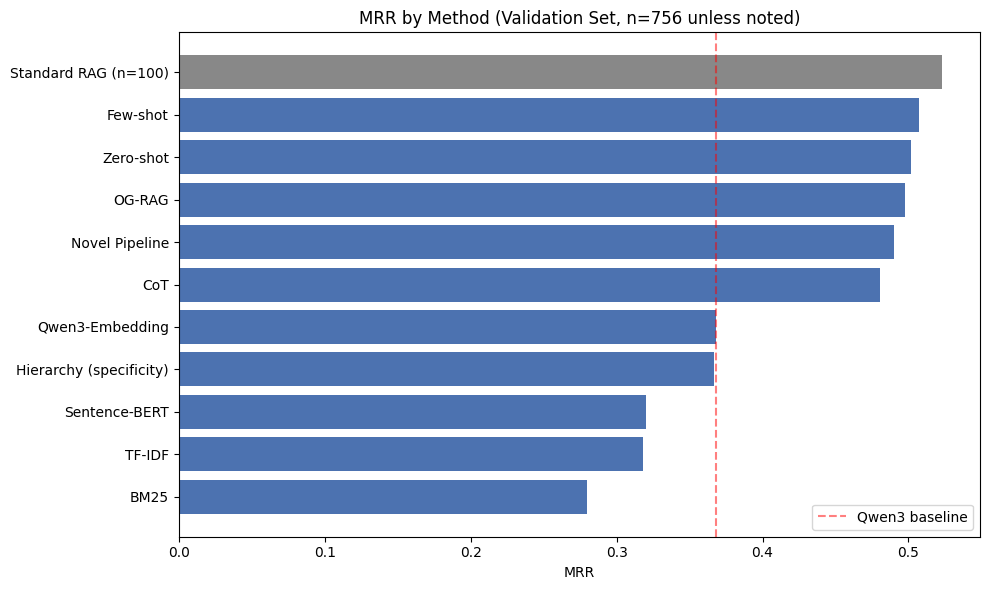

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
df_sorted = df.sort_values('MRR')
colors = ['#888888' if 'RAG (n=100)' in name else '#4c72b0' for name in df_sorted.index]
ax.barh(df_sorted.index, df_sorted['MRR'], color=colors)
ax.set_xlabel('MRR')
ax.set_title('MRR by Method (Validation Set, n=756 unless noted)')
ax.axvline(x=master_results['Qwen3-Embedding']['MRR'], color='red', linestyle='--',
           alpha=0.5, label='Qwen3 baseline')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'mrr_comparison.png'), dpi=150)
plt.show()

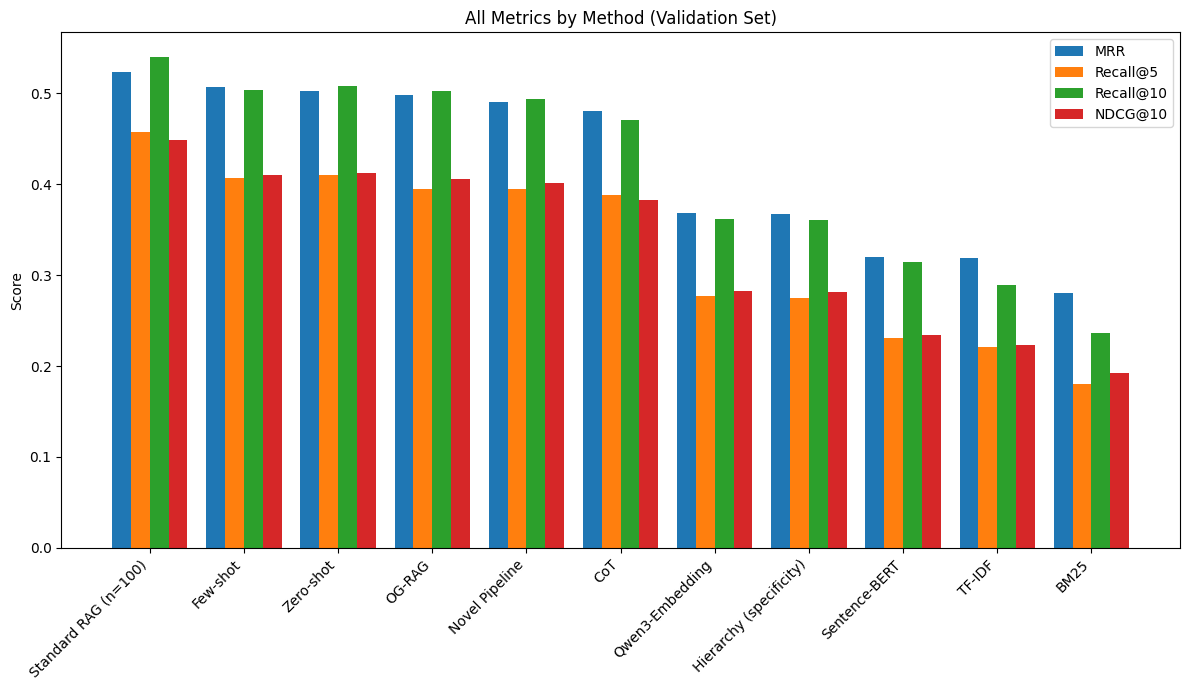

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
df_sorted = df.sort_values('MRR', ascending=False)
x = np.arange(len(df_sorted))
width = 0.2

for i, metric in enumerate(['MRR', 'Recall@5', 'Recall@10', 'NDCG@10']):
    ax.bar(x + i*width, df_sorted[metric], width, label=metric)

ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(df_sorted.index, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('All Metrics by Method (Validation Set)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'all_metrics_comparison.png'), dpi=150)
plt.show()

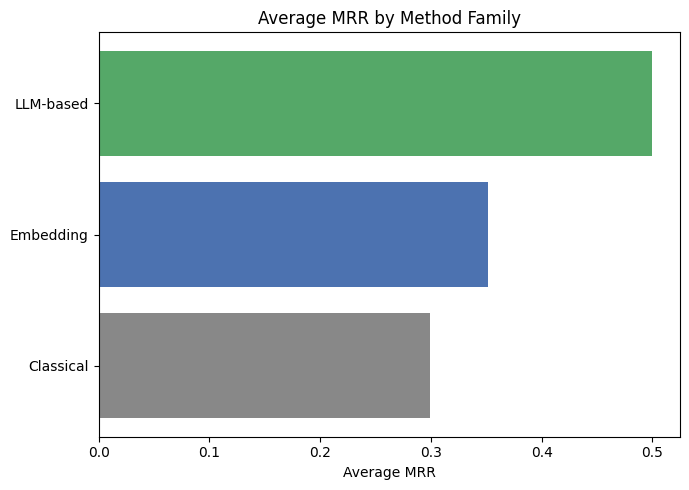

In [7]:
family_map = {
    'TF-IDF': 'Classical', 'BM25': 'Classical',
    'Sentence-BERT': 'Embedding', 'Qwen3-Embedding': 'Embedding', 'Hierarchy (specificity)': 'Embedding',
    'Zero-shot': 'LLM-based', 'Few-shot': 'LLM-based', 'CoT': 'LLM-based',
    'OG-RAG': 'LLM-based', 'Novel Pipeline': 'LLM-based', 'Standard RAG (n=100)': 'LLM-based',
}
df['Family'] = df.index.map(family_map)
family_avg = df.groupby('Family')['MRR'].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(family_avg.index, family_avg.values, color=['#888888', '#4c72b0', '#55a868'])
ax.set_xlabel('Average MRR')
ax.set_title('Average MRR by Method Family')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'family_comparison.png'), dpi=150)
plt.show()

### 12.2 Key Findings

1. **All LLM re-ranking methods substantially beat every embedding/lexical baseline** even the weakest LLM method Novel Pipeline, 0.490 clears the strongest baseline Qwen3-Embedding, 0.368 by a wide margin, confirming LLM re-ranking's core value.

2. **Among LLM methods, zero-shot, few-shot, and OG-RAG are statistically indistinguishable** pairwise Wilcoxon tests, Sections 5 and 8 despite the small numeric spread 0.497-0.507 additional prompting scaffolding worked examples, hierarchy grounding does not reliably improve on the simplest approach.

3. **CoT and the Novel Pipeline's overall figures are the two lowest among LLM methods**,
but for different well-diagnosed reasons: CoT genuinely underperforms due to incomplete re-ranking the Novel Pipeline's apparent underperformance is shown by segmented analysis to be an artifact of API non-determinism on its no conflict subset, not a real effect its actual conflict-targeted mechanism ties with zero-shot.

4. **Standard RAG's 100-document ablation shows the highest raw MRR (0.523)** but is not directly comparable to the other rows smaller, different sample and its improvement over few-shot did not reach statistical significance reported as a promising, inconclusive lead rather than a confirmed result.

5. **Hierarchy-aware retrieval, applied without an LLM, reaches parity with the strongest embedding baseline but does not exceed it** real signal exists in ELSST's structure, but extracting further gains from it alone without LLM reasoning hit a ceiling at Qwen3's level.

## 13. Difficulty Analysis
> **Approach:** Define a per-document difficulty score as the average reciprocal rank
across the five methods evaluated on the full validation set zero-shot, few-shot, CoT,
OG-RAG, Novel Pipeline excluding Standard RAG's 100-doc ablation and the non-LLM methods, since those are already known to be systematically weaker and would just re-confirm that
rather than reveal what makes a document hard. this section looks at structural properties: how many gold concepts a document has, and how long it is.
>
> **Hypothesis:** Documents with more gold concepts may be easier more chances to hit at
least one or harder more specific, narrower concepts to identify have not obvious which direction dominates without checking. Document length's effect is also unclear: longer documents give the model more context but also more room for irrelevant detail to dilute
the signal.

In [8]:
llm_methods_756 = ['Zero-shot', 'Few-shot', 'CoT', 'OG-RAG', 'Novel Pipeline']
pred_file_map = {
    'Zero-shot': 'zero_shot_predictions.json',
    'Few-shot': 'few_shot_predictions.json',
    'CoT': 'cot_predictions.json',
    'OG-RAG': 'og_rag_predictions.json',
    'Novel Pipeline': 'novel_pipeline_predictions.json',
}

all_predictions = {}
for name, fname in pred_file_map.items():
    with open(os.path.join(RESULTS_DIR, fname)) as f:
        all_predictions[name] = json.load(f)

per_doc_rows = []
for doc_id in val_ids:
    rrs = [reciprocal_rank(all_predictions[m][doc_id], gold[doc_id]) for m in llm_methods_756]
    doc_text = next(ex['text'] for ex in dataset['validation'] if ex['id'] == doc_id)
    per_doc_rows.append({
        'doc_id': doc_id,
        'avg_rr': np.mean(rrs),
        'num_gold': len(gold[doc_id]),
        'doc_length_words': len(doc_text.split()),
    })

difficulty_df = pd.DataFrame(per_doc_rows)
print(difficulty_df.describe())

           avg_rr    num_gold  doc_length_words
count  756.000000  756.000000        756.000000
mean     0.495365    2.976190        897.473545
std      0.365495    1.405557         79.591810
min      0.000000    1.000000        672.000000
25%      0.175238    2.000000        845.750000
50%      0.448333    3.000000        889.500000
75%      0.900000    4.000000        948.000000
max      1.000000    5.000000       1130.000000


### 13.1 Correlation with document structure

Avg RR vs. number of gold concepts: Spearman r=-0.129, p=0.0004
Avg RR vs. document length (words): Spearman r=0.023, p=0.5274


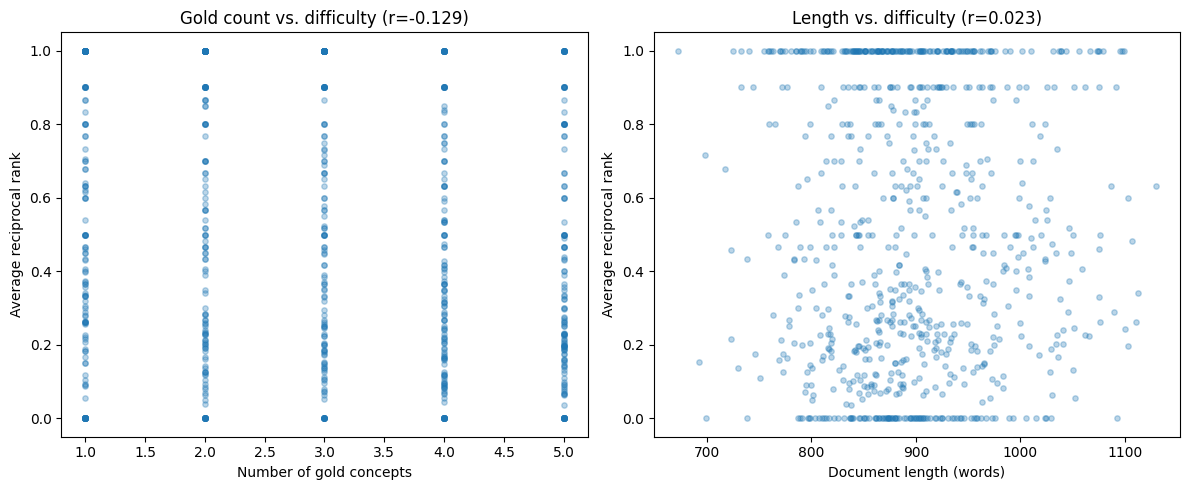

In [9]:
from scipy.stats import spearmanr

corr_gold, p_gold = spearmanr(difficulty_df['num_gold'], difficulty_df['avg_rr'])
corr_len, p_len = spearmanr(difficulty_df['doc_length_words'], difficulty_df['avg_rr'])

print(f"Avg RR vs. number of gold concepts: Spearman r={corr_gold:.3f}, p={p_gold:.4f}")
print(f"Avg RR vs. document length (words): Spearman r={corr_len:.3f}, p={p_len:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(difficulty_df['num_gold'], difficulty_df['avg_rr'], alpha=0.3, s=15)
axes[0].set_xlabel('Number of gold concepts')
axes[0].set_ylabel('Average reciprocal rank')
axes[0].set_title(f'Gold count vs. difficulty (r={corr_gold:.3f})')

axes[1].scatter(difficulty_df['doc_length_words'], difficulty_df['avg_rr'], alpha=0.3, s=15)
axes[1].set_xlabel('Document length (words)')
axes[1].set_ylabel('Average reciprocal rank')
axes[1].set_title(f'Length vs. difficulty (r={corr_len:.3f})')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'difficulty_correlations.png'), dpi=150)
plt.show()

### 13.2 Hardest and easiest documents

In [10]:
hardest = difficulty_df.nsmallest(10, 'avg_rr')
easiest = difficulty_df.nlargest(10, 'avg_rr')

print("Hardest 10 documents (avg_rr, num_gold, length):")
print(hardest.to_string(index=False))
print("\nEasiest 10 documents (avg_rr, num_gold, length):")
print(easiest.to_string(index=False))

difficulty_df.to_csv(os.path.join(RESULTS_DIR, 'difficulty_analysis.csv'), index=False)

Hardest 10 documents (avg_rr, num_gold, length):
    doc_id  avg_rr  num_gold  doc_length_words
val_v00004     0.0         1               889
val_v00038     0.0         4               891
val_v00031     0.0         2               976
val_v00033     0.0         5               810
val_v00063     0.0         4               799
val_v00061     0.0         1               937
val_v00045     0.0         2              1025
val_v00053     0.0         1               918
val_v00041     0.0         3               880
val_v00062     0.0         2               797

Easiest 10 documents (avg_rr, num_gold, length):
    doc_id  avg_rr  num_gold  doc_length_words
val_v00029     1.0         2               799
val_v00002     1.0         2               880
val_v00030     1.0         1               976
val_v00040     1.0         3               841
val_v00019     1.0         4               733
val_v00037     1.0         2               878
val_v00026     1.0         2               943
val_v000

## 14. Hard Negatives Analysis
> **Approach:** Using zero-shot's predictions the simplest tied-best method, avoiding confounds from routing logic or worked examples, identify which incorrect concepts most
frequently appear in the top-5 across the validation set these are the hard negatives the model consistently favors over the correct answer.
>
> **Key question, tying back to Sections 7 and 9:** are these hard negatives dominated by hierarchy-related confusions a broader/narrower relative of the actual gold concept: the HOUSING/HIGH RISE FLATS pattern, or is something else driving most errors? This directly tests whether that mechanism, which motivated the novel pipeline, is actually the dominant error source or just one example among many.

In [12]:
from huggingface_hub import hf_hub_download

pool_path = hf_hub_download(repo_id="JohnWang10086/elsst-track1", filename="concept_pool.jsonl", repo_type="dataset")
concept_pool_lookup = {}
with open(pool_path, "r") as f:
    for line in f:
        c = json.loads(line)
        concept_pool_lookup[c["concept_id"]] = c

print(f"Loaded {len(concept_pool_lookup)} concepts")

concept_pool.jsonl:   0%|          | 0.00/800k [00:00<?, ?B/s]

Loaded 3433 concepts


### 14.1 False positives and hierarchy confusion
> For every document, checking each top-5 false positive against whether it's an ELSST neighbor of a gold concept in that same document testing whether the HOUSING/HIGH RISE FLATS style confusion Sections 7 and 9 is the dominant error source, or just one mechanism among several.

In [13]:
with open(os.path.join(RESULTS_DIR, 'zero_shot_predictions.json')) as f:
    zero_shot_predictions = json.load(f)

with open(os.path.join(RESULTS_DIR, 'concept_hierarchy_strict.json')) as f:
    concept_neighbors_raw = json.load(f)
concept_neighbors = {cid: set(neighbors) for cid, neighbors in concept_neighbors_raw.items()}

from collections import Counter

hard_negative_counts = Counter()
hierarchy_confusion_count = 0
total_fp_instances = 0

for doc_id in val_ids:
    ranked = zero_shot_predictions[doc_id]
    gold_set = set(gold[doc_id])
    top5 = ranked[:5]
    false_positives = [cid for cid in top5 if cid not in gold_set]

    for fp in false_positives:
        hard_negative_counts[fp] += 1
        total_fp_instances += 1
        fp_neighbors = concept_neighbors.get(fp, set())
        if fp_neighbors & gold_set:
            hierarchy_confusion_count += 1

print(f"Total false-positive instances in top-5 across {len(val_ids)} documents: {total_fp_instances}")
print(f"Hierarchy-related to a gold concept in the same document: "
      f"{hierarchy_confusion_count} ({100*hierarchy_confusion_count/total_fp_instances:.1f}%)")

print(f"\nTop 15 most frequent hard-negative concepts:")
for cid, count in hard_negative_counts.most_common(15):
    print(f"  {concept_pool_lookup[cid]['term']:40s} false positive in {count} documents")

Total false-positive instances in top-5 across 756 documents: 3055
Hierarchy-related to a gold concept in the same document: 246 (8.1%)

Top 15 most frequent hard-negative concepts:
  REGIONAL DEVELOPMENT                     false positive in 32 documents
  DIGITAL TRANSFORMATION                   false positive in 31 documents
  URBAN RENEWAL                            false positive in 26 documents
  RURAL DEVELOPMENT                        false positive in 26 documents
  REGIONAL ECONOMY                         false positive in 25 documents
  DIGITAL DIVIDE                           false positive in 24 documents
  URBAN DEVELOPMENT                        false positive in 23 documents
  DEPRESSED AREAS                          false positive in 23 documents
  WORKING CONDITIONS                       false positive in 23 documents
  ENERGY TRANSITION                        false positive in 23 documents
  LABOUR SHORTAGES                         false positive in 21 documents
  CO

### 14.2 Concentration of errors
> Checking whether errors cluster on a small set of generic 'attractor' concepts, or are spread thinly across many different, mostly document-specific near misses.

In [14]:
print(f"Total unique concepts appearing as a hard negative at least once: {len(hard_negative_counts)}")

top15_total = sum(count for _, count in hard_negative_counts.most_common(15))
print(f"Top 15 hard negatives account for {top15_total}/{total_fp_instances} "
      f"({100*top15_total/total_fp_instances:.1f}%) of all false positives")

most_frequent_share = hard_negative_counts.most_common(1)[0][1] / len(val_ids)
print(f"Most frequent hard negative appears in {100*most_frequent_share:.1f}% of all documents")

Total unique concepts appearing as a hard negative at least once: 1055
Top 15 hard negatives account for 354/3055 (11.6%) of all false positives
Most frequent hard negative appears in 4.2% of all documents


## 15. Genre Breakdown
> **Approach:** Group validation documents by `document_type` e.g. encyclopedia entries,
blog posts, forum discussions and compare MRR within each genre, using the same five
full-validation LLM methods as Section 13's difficulty analysis for consistency.
>
> **Hypothesis:** The "show, don't tell" framing may affect genres differently narrative
or conversational genres blog posts, forum discussions might rely more heavily on implicit, situational cues, while more expository genres encyclopedia entries may state things more directly despite the benchmark's overall design intent. Worth checking rather than assuming.

In [15]:
doc_type_map = {ex['id']: ex['document_type'] for ex in dataset['validation']}
genre_counts = Counter(doc_type_map.values())
print("Genre distribution in validation set:")
for genre, count in genre_counts.most_common():
    print(f"  {genre:24s} {count} documents")

Genre distribution in validation set:
  interview_transcript     77 documents
  forum_discussion         76 documents
  policy_brief             76 documents
  blog_post                76 documents
  case_study               76 documents
  encyclopedia_entry       75 documents
  news_article             75 documents
  research_summary         75 documents
  report_excerpt           75 documents
  op_ed                    75 documents


### 15.1 MRR by genre, per method

method                  CoT  Few-shot  Novel Pipeline  OG-RAG  Zero-shot  \
genre                                                                      
blog_post             0.412     0.451           0.424   0.454      0.435   
case_study            0.423     0.477           0.457   0.453      0.501   
encyclopedia_entry    0.613     0.640           0.602   0.572      0.590   
forum_discussion      0.541     0.552           0.552   0.547      0.594   
interview_transcript  0.509     0.528           0.487   0.486      0.520   
news_article          0.549     0.589           0.565   0.572      0.580   
op_ed                 0.488     0.457           0.481   0.482      0.473   
policy_brief          0.382     0.439           0.406   0.458      0.427   
report_excerpt        0.423     0.473           0.460   0.470      0.422   
research_summary      0.466     0.466           0.466   0.481      0.479   

method                n_docs  
genre                         
blog_post                

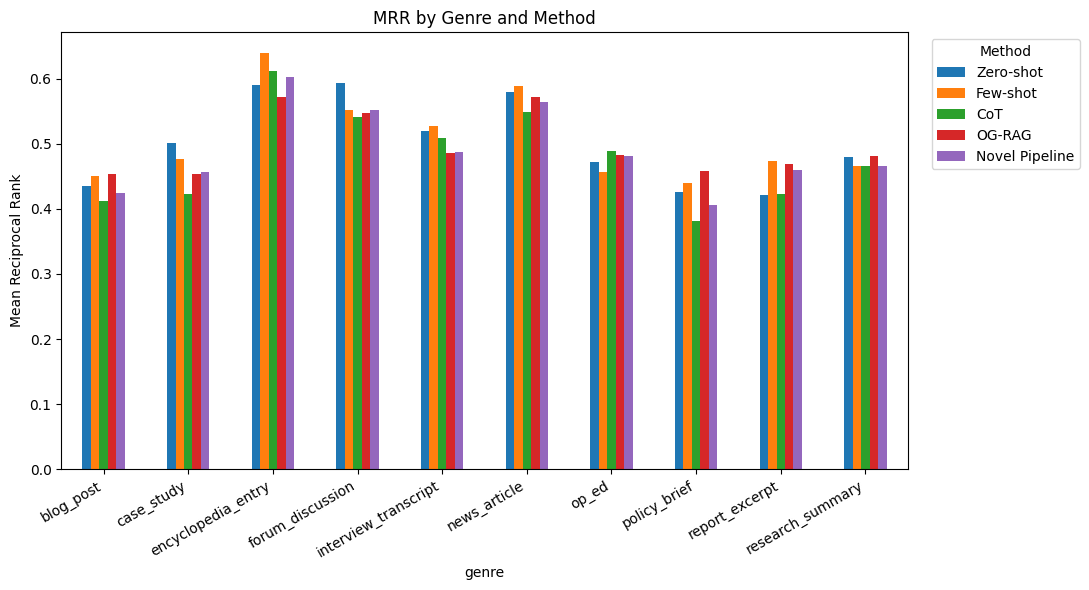

In [16]:
genre_rows = []
for doc_id in val_ids:
    genre = doc_type_map[doc_id]
    for method in llm_methods_756:
        rr = reciprocal_rank(all_predictions[method][doc_id], gold[doc_id])
        genre_rows.append({'genre': genre, 'method': method, 'rr': rr})

genre_df = pd.DataFrame(genre_rows)
genre_pivot = genre_df.groupby(['genre', 'method'])['rr'].mean().unstack()
genre_pivot['n_docs'] = genre_df[genre_df['method'] == 'Zero-shot'].groupby('genre').size()
print(genre_pivot.round(3))

fig, ax = plt.subplots(figsize=(11, 6))
genre_pivot[llm_methods_756].plot(kind='bar', ax=ax)
ax.set_ylabel('Mean Reciprocal Rank')
ax.set_title('MRR by Genre and Method')
ax.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'genre_breakdown.png'), dpi=150)
plt.show()

### 15.2 Is genre a significant factor?

In [17]:
from scipy.stats import kruskal

zero_shot_by_genre = [genre_df[(genre_df['genre'] == g) & (genre_df['method'] == 'Zero-shot')]['rr'].values
                       for g in genre_counts.keys()]
stat, p = kruskal(*zero_shot_by_genre)
print(f"Kruskal-Wallis test across genres (zero-shot MRR): H={stat:.3f}, p={p:.4f}")

Kruskal-Wallis test across genres (zero-shot MRR): H=19.891, p=0.0186


In [18]:
for method in ['Few-shot', 'OG-RAG', 'Novel Pipeline']:
    method_by_genre = [genre_df[(genre_df['genre'] == g) & (genre_df['method'] == method)]['rr'].values
                        for g in genre_counts.keys()]
    stat, p = kruskal(*method_by_genre)
    print(f"{method:16s} H={stat:.3f}, p={p:.4f}")

Few-shot         H=19.586, p=0.0206
OG-RAG           H=12.291, p=0.1974
Novel Pipeline   H=18.487, p=0.0299


## 16. Qualitative Error Analysis
> **Approach:** Sections 13-15 identified where difficulty concentrates certain genres
but not why in a way statistics alone can show. This section reads actual documents and predictions directly pulling from the hardest documents and hardest genres Section 15: policy_brief, blog_post to see what the text actually says versus what the
model predicted, and to check whether Section 14's error patterns hierarchy confusion,
generic hard negatives are visible at the individual document level or something else entirely is going on.

In [19]:
difficulty_df['genre'] = difficulty_df['doc_id'].map(doc_type_map)

hard_from_hard_genre = difficulty_df[
    (difficulty_df['avg_rr'] < 0.2) &
    (difficulty_df['genre'].isin(['policy_brief', 'blog_post']))
].sort_values('avg_rr').head(3)

print("Hard documents from the hardest genres:")
print(hard_from_hard_genre[['doc_id', 'avg_rr', 'genre', 'num_gold']].to_string(index=False))

Hard documents from the hardest genres:
    doc_id  avg_rr        genre  num_gold
val_v00031     0.0 policy_brief         2
val_v00061     0.0 policy_brief         1
val_v00063     0.0    blog_post         4


### 16.1 Close reading of three hard cases

In [21]:
def inspect_document(doc_id, n_preview_words=120):
    doc_text = next(ex['text'] for ex in dataset['validation'] if ex['id'] == doc_id)
    gold_terms = [concept_pool_lookup[c]['term'] for c in gold[doc_id]]
    zs_top5 = zero_shot_predictions[doc_id][:5]
    zs_top5_terms = [concept_pool_lookup[c]['term'] for c in zs_top5]

    print(f" {doc_id} ({doc_type_map[doc_id]}) ")
    print(f"Opening: {' '.join(doc_text.split()[:n_preview_words])}...\n")
    print(f"Gold concepts:        {gold_terms}")
    print(f"Zero-shot top-5:      {zs_top5_terms}")
    hits = set(zs_top5) & set(gold[doc_id])
    print(f"Correctly matched:    {[concept_pool_lookup[c]['term'] for c in hits] if hits else 'none'}")
    print()

for doc_id in hard_from_hard_genre['doc_id']:
    inspect_document(doc_id)

 val_v00031 (policy_brief) 
Opening: POLICY BRIEF: STRENGTHENING LABOR STANDARDS FOR DOMESTIC STAFF IN URBAN GULF CENTERS EXECUTIVE SUMMARY The rapid urbanization of the Gulf Cooperation Council (GCC) region has necessitated a fundamental shift in how private households manage the individuals who maintain them. While recent legislative updates in jurisdictions like the United Arab Emirates and Qatar have introduced standardized templates for those coming from abroad to work in homes, a significant gap remains between the text of these documents and the daily reality of the household. Current trends indicate a move toward modernization, yet the residency status of these workers remains precariously tied to the personal approval of a single head of household. This brief argues for a complete decoupling of legal residency from...

Gold concepts:        ['EMPLOYMENT CONTRACTS', 'MARRIAGE CONTRACTS']
Zero-shot top-5:      ['DOMESTIC WORKERS', 'SERVANTS', 'LABOUR POLICY', 'TIED HOUSING', 'FO

### 16.2 Reading the full document behind the most surprising case
> val_v00031's opening 120 words didn't obviously connect to its gold concept MARRIAGE CONTRACTS reading the complete document to check whether the connection appears later in the text, or whether something else explains the miss.

In [22]:
full_text = next(ex['text'] for ex in dataset['validation'] if ex['id'] == 'val_v00031')
print(full_text)

POLICY BRIEF: STRENGTHENING LABOR STANDARDS FOR DOMESTIC STAFF IN URBAN GULF CENTERS

EXECUTIVE SUMMARY

The rapid urbanization of the Gulf Cooperation Council (GCC) region has necessitated a fundamental shift in how private households manage the individuals who maintain them. While recent legislative updates in jurisdictions like the United Arab Emirates and Qatar have introduced standardized templates for those coming from abroad to work in homes, a significant gap remains between the text of these documents and the daily reality of the household. Current trends indicate a move toward modernization, yet the residency status of these workers remains precariously tied to the personal approval of a single head of household. This brief argues for a complete decoupling of legal residency from private household agreements and the enforcement of professional boundaries that distinguish a job from a personal or familial obligation.

A HISTORICAL OVERLAP OF PRIVATE BONDS

Historically, the pr

In [24]:
with open(os.path.join(RESULTS_DIR, 'qwen_predictions.json')) as f:
    qwen_predictions = json.load(f)

### 16.3 Checking whether the gold concepts were even retrievable
> The full text reveals a sustained analogy to marriage throughout so truncation isn't the issue. Checking directly whether MARRIAGE CONTRACTS and EMPLOYMENT CONTRACTS were ever in Qwen3's top-50 shortlist to begin with, since no re-ranking method can recover a concept the first stage never surfaced.

In [25]:
qwen_shortlist = qwen_predictions['val_v00031']
marriage_id = next(cid for cid, c in concept_pool_lookup.items() if c['term'] == 'MARRIAGE CONTRACTS')

if marriage_id in qwen_shortlist:
    position = qwen_shortlist.index(marriage_id) + 1
    print(f"MARRIAGE CONTRACTS is in Qwen3's top-50, at rank {position}")
else:
    print("MARRIAGE CONTRACTS is NOT in Qwen3's top-50 shortlist at all")

employment_id = next(cid for cid, c in concept_pool_lookup.items() if c['term'] == 'EMPLOYMENT CONTRACTS')
if employment_id in qwen_shortlist:
    position = qwen_shortlist.index(employment_id) + 1
    print(f"EMPLOYMENT CONTRACTS is in Qwen3's top-50, at rank {position}")
else:
    print("EMPLOYMENT CONTRACTS is NOT in Qwen3's top-50 shortlist at all")

MARRIAGE CONTRACTS is NOT in Qwen3's top-50 shortlist at all
EMPLOYMENT CONTRACTS is NOT in Qwen3's top-50 shortlist at all


### 16.4 Quantifying the retrieval ceiling across the whole validation set
> Neither gold concept was in the shortlist for this one document checking how common this 'retrieval ceiling' effect is across all 756 validation documents, not just this one traced example.

In [26]:
retrieval_ceiling_misses = 0
for doc_id in val_ids:
    shortlist_set = set(qwen_predictions[doc_id])
    gold_set = set(gold[doc_id])
    if not (shortlist_set & gold_set):
        retrieval_ceiling_misses += 1

print(f"Documents where NONE of the gold concepts appear in Qwen3's top-50: "
      f"{retrieval_ceiling_misses}/{len(val_ids)} ({100*retrieval_ceiling_misses/len(val_ids):.1f}%)")

Documents where NONE of the gold concepts appear in Qwen3's top-50: 95/756 (12.6%)


### 16.5 Isolating the re-ranking stage's true performance
> Recomputing zero-shot's MRR restricted to only the documents where the answer was at least present in the shortlist, to separate the re-ranking stage's genuine quality from the retrieval-stage ceiling it's stuck with.

In [27]:
achievable_ids = [doc_id for doc_id in val_ids
                  if set(qwen_predictions[doc_id]) & set(gold[doc_id])]

print(f"Documents where the answer was retrievable: {len(achievable_ids)}/{len(val_ids)}")

achievable_gold = {doc_id: gold[doc_id] for doc_id in achievable_ids}
achievable_preds = {doc_id: zero_shot_predictions[doc_id] for doc_id in achievable_ids}
achievable_metrics = evaluate_retrieval(achievable_preds, achievable_gold)

print(f"\nZero-shot MRR across ALL 756 documents: 0.5021")
print(f"Zero-shot MRR on the {len(achievable_ids)} 'achievable' documents only: {achievable_metrics['MRR']:.4f}")

Documents where the answer was retrievable: 661/756

Zero-shot MRR across ALL 756 documents: 0.5021
Zero-shot MRR on the 661 'achievable' documents only: 0.5742


## 17. Summary of Analysis Chapter

This chapter examined why the methods in Sections 3-9 perform as they do, beyond the
headline numbers.

1. **LLM re-ranking is the single biggest driver of performance** every LLM-based method substantially outperforms every embedding/lexical baseline, confirming the core value of adding an LLM re-ranking stage on top of embedding retrieval.

2. **Among LLM methods, additional scaffolding rarely helps** zero-shot, few-shot, and
OG-RAG are statistically indistinguishable; CoT is a genuine regression; the novel pipeline's apparent underperformance is most likely an artifact of API non-determinism rather than a
real effect, once segmented properly by document subset. Simplicity is hard to beat here.

3. **Document length and gold-concept count do not meaningfully explain difficulty**
Section 13 but **genre does**, and by a much larger margin Section 15: expository
genres encyclopedia entries are consistently easier than persuasive or conversational ones policy briefs, blog posts, a pattern that held across most methods tested.

4. **Errors are not concentrated on a few systematic biases** Section 14 hierarchy confusion accounts for only 8.1% of false positives, and no small set of "attractor" concepts
dominates the remainder. Most errors are individually rare, document-specific near-misses.

5. **The most significant finding of this chapter: a hard retrieval ceiling** Section 16 12.6% of validation documents have no gold concept anywhere in Qwen3's top-50 shortlist,
meaning no re-ranking method could ever succeed on them regardless of prompt quality.
Restricting to only the "achievable" documents, zero-shot's MRR rises from 0.502 to 0.574 showing the re-ranking stage performs considerably better than the headline number suggests,
and that the true bottleneck on this pipeline's overall performance is the initial embedding retrieval stage, not the LLM's reasoning.

**Limitations:** significance tests across this project were not corrected for multiple
comparisons Section 15's genre effect is confirmed overall but specific pairwise genre
differences were not tested individually Section 9's non-determinism conclusion, while well evidenced, is stated as the most likely explanation rather than an absolute certainty.